<div style="background:linear-gradient(135deg,#1e1b4b 0%,#4338ca 55%,#6366f1 100%);border-radius:18px;padding:34px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#c7d2fe;font-weight:700;text-transform:uppercase">Chapter 31 · Part VI Probability</div>
  <div style="font-size:34px;font-weight:900;line-height:1.1;margin:10px 0 6px">Rules of Probability ➕✖️</div>
  <div style="font-size:15px;color:#e0e7ff;max-width:720px;line-height:1.6">How to combine probabilities: the addition rule for OR, the multiplication rule for AND, and the crucial difference between mutually exclusive and independent events.</div>
  <div style="margin-top:16px;font-size:13px;color:#cbd5e1">Statistics, Data Science and AI: A Visual Handbook · John Fisher · 2026</div>
</div>

## ⚙️ Setup

In [1]:
import numpy as np, matplotlib.pyplot as plt
import matplotlib.patches as mpatches
rng = np.random.default_rng(31)
BLUE="#2563eb"; INDIGO="#4f46e5"; GREEN="#059669"; AMBER="#d97706"; PURPLE="#7c3aed"; PINK="#db2777"; INK="#1a2138"; GRID="#e6e9f2"
plt.rcParams.update({"figure.facecolor":"white","axes.facecolor":"white","figure.dpi":110,"font.size":11,
   "axes.edgecolor":GRID,"axes.grid":True,"grid.color":GRID,"axes.axisbelow":True,"axes.spines.top":False,
   "axes.spines.right":False,"axes.titlesize":12,"axes.titleweight":"bold","legend.frameon":False})
print("ready")

ready


<div style="background:#eef2ff;border-left:5px solid #4f46e5;border-radius:10px;padding:15px 20px;font-family:Inter,sans-serif">
<span style="font-size:12px;font-weight:800;color:#4f46e5;letter-spacing:1px">DEMO 1 · ADDITION RULE</span>
<div style="font-size:20px;font-weight:800;color:#1a2138;margin-top:3px">P(A or B), and why we subtract</div>
<div style="color:#4a5578;margin-top:6px;line-height:1.6">Draw one card from a 52-card deck. What is P(heart OR face card)? Adding P(heart) + P(face) double-counts the cards that are both, so the <b>addition rule</b> subtracts the overlap.</div>
</div>

P(heart)            = 13/52 = 0.250
P(face)             = 12/52 = 0.231
P(heart AND face)   =  3/52 = 0.058
P(heart OR face)    = 0.250 + 0.231 - 0.058 = 0.423


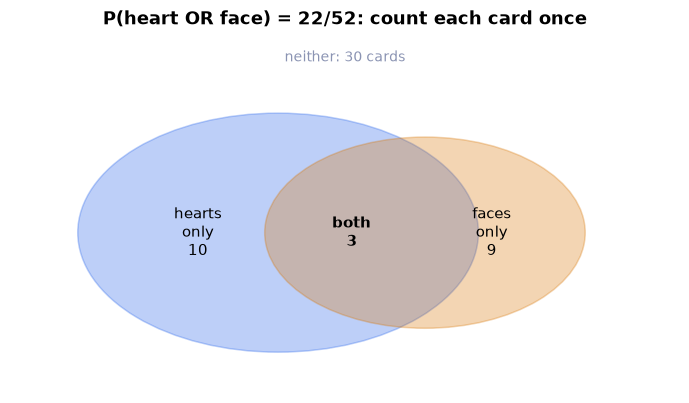

In [2]:
hearts = 13; faces = 12; heart_faces = 3      # J,Q,K of hearts
p_h = hearts/52; p_f = faces/52; p_both = heart_faces/52
p_or = p_h + p_f - p_both
print(f"P(heart)            = 13/52 = {p_h:.3f}")
print(f"P(face)             = 12/52 = {p_f:.3f}")
print(f"P(heart AND face)   =  3/52 = {p_both:.3f}")
print(f"P(heart OR face)    = {p_h:.3f} + {p_f:.3f} - {p_both:.3f} = {p_or:.3f}")

# a Venn picture of the deck
fig, ax = plt.subplots(figsize=(6.4,3.8))
ax.add_patch(mpatches.Circle((0.40,0.5),0.30, color=BLUE, alpha=0.30))
ax.add_patch(mpatches.Circle((0.62,0.5),0.24, color=AMBER, alpha=0.30))
ax.text(0.28,0.5,"hearts\nonly\n10",ha="center",va="center",fontsize=10)
ax.text(0.51,0.5,"both\n3",ha="center",va="center",fontsize=10,fontweight="bold")
ax.text(0.72,0.5,"faces\nonly\n9",ha="center",va="center",fontsize=10)
ax.text(0.5,0.93,"neither: 30 cards",ha="center",fontsize=9,color="#8b94b3")
ax.set_xlim(0,1); ax.set_ylim(0.1,1); ax.axis("off"); ax.set_title("P(heart OR face) = 22/52: count each card once")
plt.tight_layout(); plt.show()

**Why subtract?** The 3 cards that are *both* a heart and a face card get counted in P(heart) and again in P(face). Subtracting P(A and B) once corrects the double-count. This is the general addition rule: **P(A or B) = P(A) + P(B) - P(A and B)**.

<div style="background:#eef2ff;border-left:5px solid #4f46e5;border-radius:10px;padding:15px 20px;font-family:Inter,sans-serif">
<span style="font-size:12px;font-weight:800;color:#2563eb;letter-spacing:1px">DEMO 2 · MUTUALLY EXCLUSIVE</span>
<div style="font-size:20px;font-weight:800;color:#1a2138;margin-top:3px">When the overlap is zero</div>
<div style="color:#4a5578;margin-top:6px;line-height:1.6">If two events cannot both happen, they are <b>mutually exclusive</b>, the overlap term is 0, and the addition rule simplifies to plain addition.</div>
</div>

In [3]:
# one die: events {roll a 1} and {roll a 6} cannot both occur
p1, p6 = 1/6, 1/6
print(f"P(1 or 6) = P(1) + P(6) = {p1:.3f} + {p6:.3f} = {p1+p6:.3f}   (no overlap to subtract)")
print(f"P(1 AND 6) = 0  -> the events are mutually exclusive")

rolls = rng.integers(1,7,200_000)
emp = np.mean((rolls==1) | (rolls==6))
print(f"empirical P(1 or 6) over 200k rolls = {emp:.3f}")

P(1 or 6) = P(1) + P(6) = 0.167 + 0.167 = 0.333   (no overlap to subtract)
P(1 AND 6) = 0  -> the events are mutually exclusive
empirical P(1 or 6) over 200k rolls = 0.331


**The special case.** For mutually exclusive events P(A and B) = 0, so P(A or B) = P(A) + P(B). On one die you cannot roll a 1 and a 6 at the same time, so the probabilities simply add to 1/3.

<div style="background:#eef2ff;border-left:5px solid #4f46e5;border-radius:10px;padding:15px 20px;font-family:Inter,sans-serif">
<span style="font-size:12px;font-weight:800;color:#059669;letter-spacing:1px">DEMO 3 · MULTIPLICATION RULE</span>
<div style="font-size:20px;font-weight:800;color:#1a2138;margin-top:3px">P(A and B) for independent events</div>
<div style="color:#4a5578;margin-top:6px;line-height:1.6">For an AND across <b>independent</b> events (one does not affect the other), probabilities multiply: P(A and B) = P(A) x P(B).</div>
</div>

In [4]:
# two dice: P(both even). Each die: P(even)=3/6
p_even = 3/6
p_both_even = p_even * p_even
print(f"P(both dice even) = P(even) x P(even) = {p_even} x {p_even} = {p_both_even:.3f}")

d = rng.integers(1,7,(300_000,2))
emp = np.mean((d[:,0]%2==0) & (d[:,1]%2==0))
print(f"empirical (300k rolls)              = {emp:.3f}")
print("\nGeneral form (any AND): P(A and B) = P(A) x P(B|A).")
print("When A and B are independent, P(B|A) = P(B), so it reduces to P(A) x P(B).")

P(both dice even) = P(even) x P(even) = 0.5 x 0.5 = 0.250
empirical (300k rolls)              = 0.251

General form (any AND): P(A and B) = P(A) x P(B|A).
When A and B are independent, P(B|A) = P(B), so it reduces to P(A) x P(B).


**Multiply along the AND.** Two dice are independent, so the chance both are even is just the product, 1/2 x 1/2 = 1/4. The general rule uses the *conditional* probability P(B given A), which the next chapter develops in full; for independent events that conditional equals P(B) and the rule simplifies to a plain product.

<div style="background:#eef2ff;border-left:5px solid #4f46e5;border-radius:10px;padding:15px 20px;font-family:Inter,sans-serif">
<span style="font-size:12px;font-weight:800;color:#db2777;letter-spacing:1px">DEMO 4 · A CRUCIAL DIFFERENCE</span>
<div style="font-size:20px;font-weight:800;color:#1a2138;margin-top:3px">Mutually exclusive is NOT independent</div>
<div style="color:#4a5578;margin-top:6px;line-height:1.6">These two ideas get confused constantly. <b>Mutually exclusive</b> means both cannot happen (P(A and B)=0). <b>Independent</b> means one does not change the other (P(A and B)=P(A)xP(B)). The test below shows they are different.</div>
</div>

ONE DIE: A=even, B=odd
  P(A and B) = 0.0   P(A)xP(B) = 0.250   independent? False
  -> mutually exclusive, and therefore NOT independent (each makes the other impossible)

TWO DICE: A=die1 even, B=die2 is 6
  P(A and B) = 0.083   P(A)xP(B) = 0.083   independent? True
  -> can both happen, and one does not affect the other: independent


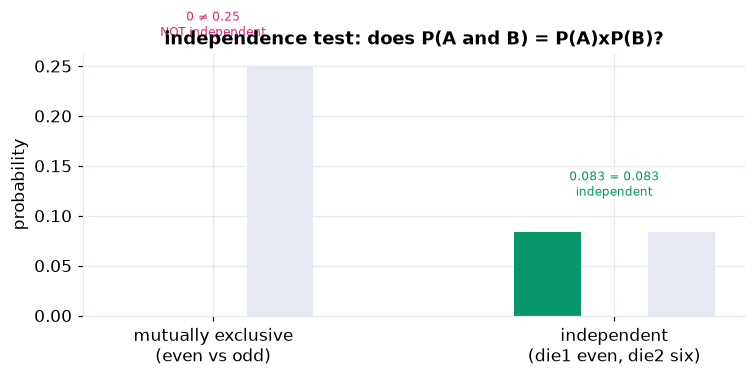

In [5]:
def is_independent(pA, pB, pAB): return np.isclose(pAB, pA*pB)

# Scenario 1 (one die): A={even}, B={odd}  -> mutually exclusive
pA, pB, pAB = 3/6, 3/6, 0.0
print("ONE DIE: A=even, B=odd")
print(f"  P(A and B) = {pAB}   P(A)xP(B) = {pA*pB:.3f}   independent? {is_independent(pA,pB,pAB)}")
print("  -> mutually exclusive, and therefore NOT independent (each makes the other impossible)\n")

# Scenario 2 (two dice): A={die1 even}, B={die2 is 6}  -> independent
pA, pB, pAB = 3/6, 1/6, (3/6)*(1/6)
print("TWO DICE: A=die1 even, B=die2 is 6")
print(f"  P(A and B) = {pAB:.3f}   P(A)xP(B) = {pA*pB:.3f}   independent? {is_independent(pA,pB,pAB)}")
print("  -> can both happen, and one does not affect the other: independent")

fig, ax = plt.subplots(figsize=(7,3.6))
labels=["A and B","P(A)xP(B)"]
ax.bar([0,1],[0.0,(3/6)*(3/6)],width=0.5,color=[PINK,GRID]); 
ax.bar([3,4],[(3/6)*(1/6),(3/6)*(1/6)],width=0.5,color=[GREEN,GRID])
ax.set_xticks([0.5,3.5]); ax.set_xticklabels(["mutually exclusive\n(even vs odd)","independent\n(die1 even, die2 six)"])
ax.set_ylabel("probability"); ax.set_title("independence test: does P(A and B) = P(A)xP(B)?")
ax.text(0.5,0.28,"0 ≠ 0.25\nNOT independent",ha="center",fontsize=8,color=PINK)
ax.text(3.5,0.12,"0.083 = 0.083\nindependent",ha="center",fontsize=8,color=GREEN)
plt.tight_layout(); plt.show()

**The litmus test.** Independence is defined by P(A and B) = P(A) x P(B). Mutually exclusive events fail it badly: P(A and B) = 0 while P(A) x P(B) > 0, so mutually exclusive events are in fact strongly *dependent*. The two terms are not opposites and not synonyms; always test, never assume.

<div style="background:#eef2ff;border-left:5px solid #4f46e5;border-radius:10px;padding:15px 20px;font-family:Inter,sans-serif">
<span style="font-size:12px;font-weight:800;color:#d97706;letter-spacing:1px">DEMO 5 · COMBINING RULES</span>
<div style="font-size:20px;font-weight:800;color:#1a2138;margin-top:3px">'At least one' via the complement</div>
<div style="color:#4a5578;margin-top:6px;line-height:1.6">Many real questions are "at least one". The clean route combines the multiplication rule with the complement: P(at least one) = 1 - P(none).</div>
</div>

P(at least one six in 1 rolls) = 1 - (5/6)^1 = 0.167
P(at least one six in 2 rolls) = 1 - (5/6)^2 = 0.306
P(at least one six in 4 rolls) = 1 - (5/6)^4 = 0.518
P(at least one six in 6 rolls) = 1 - (5/6)^6 = 0.665


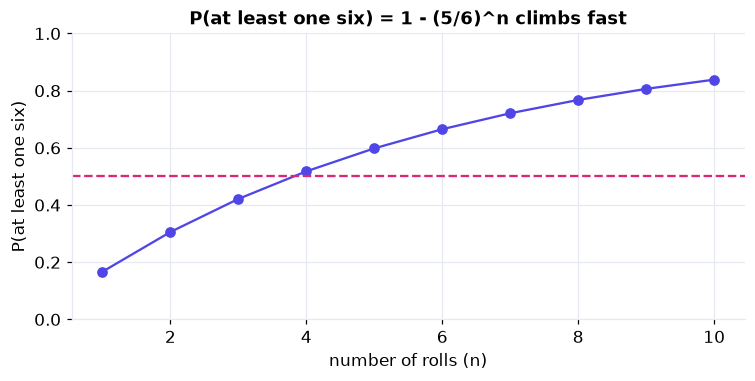


It passes 50% at n=4 -- a handy gambling fact: four rolls to favor at least one six.


In [6]:
ns = np.arange(1, 11)
p_at_least_one = 1 - (5/6)**ns          # at least one six in n rolls
for n in [1,2,4,6]:
    print(f"P(at least one six in {n} rolls) = 1 - (5/6)^{n} = {1-(5/6)**n:.3f}")

fig, ax = plt.subplots(figsize=(7,3.6))
ax.plot(ns, p_at_least_one, "o-", color=INDIGO)
ax.axhline(0.5, ls="--", color=PINK); ax.set_ylim(0,1)
ax.set_xlabel("number of rolls (n)"); ax.set_ylabel("P(at least one six)")
ax.set_title("P(at least one six) = 1 - (5/6)^n climbs fast"); plt.tight_layout(); plt.show()
print("\nIt passes 50% at n=4 -- a handy gambling fact: four rolls to favor at least one six.")

**Build from the pieces.** "None" is an AND of independent failures, (5/6) every roll, so P(none) = (5/6)^n by the multiplication rule; the complement flips it into "at least one". The probability climbs quickly and crosses one half at the fourth roll.

---
<div style="background:#ffffff;border:1px solid #e6e9f2;border-radius:16px;padding:22px 26px;font-family:Inter,sans-serif">
<div style="font-size:19px;font-weight:800;color:#1a2138">🎯 Recap</div>
<ul style="color:#4a5578;line-height:1.9;margin-top:8px">
<li><b>Addition (OR):</b> P(A or B) = P(A) + P(B) - P(A and B); subtract the overlap so nothing is double-counted.</li>
<li><b>Multiplication (AND):</b> P(A and B) = P(A) x P(B|A); for independent events this is just P(A) x P(B).</li>
<li><b>Mutually exclusive</b> (P(A and B)=0) is NOT the same as <b>independent</b> (P(A and B)=P(A)xP(B)).</li>
<li><b>"At least one"</b> = 1 - P(none): combine multiplication with the complement.</li>
</ul>
</div>

<div style="text-align:center;color:#8b94b3;font-size:12px;margin-top:16px">Statistics, Data Science and AI: A Visual Handbook · © 2026 John Fisher</div>